# 🧬 Cuaderno 02 Alineamiento de Secuencias

**Curso:** Bioinformática
**Repositorio:** `bio-notebooks`  
**Herramientas:** Python 3, numpy, matplotlib, biopython

## Competencias
- Implementar el algoritmo Smith-Waterman usando programación dinámica
- Analizar similitud entre secuencias biológicas
- Comparar el efecto de distintos parámetros de penalización

## Contenido
1. Marco teórico
2. Parámetros de puntuación
3. Implementación Smith-Waterman
4. Implementación Needleman-Wunsch
5. Demostración con matrices pequeñas
6. Lectura de secuencias reales desde archivos FASTA
7. Descarga alternativa con Biopython
8. Análisis BRCA1 humano vs ratón
9. Efecto del gap en el alineamiento
10. Medición de tiempo con secuencias largas
11. Heatmap con camino del traceback


## 1. Marco Teórico

### 1.1 ¿Por qué alinear secuencias?

El alineamiento responde a: *¿qué tan similares son dos secuencias biológicas?*

Es fundamental para:
- Identificar genes homólogos entre especies
- Predecir función de secuencias desconocidas
- Estudiar evolución molecular
- Detectar mutaciones patogénicas

### 1.2 Tipos de alineamiento

| Tipo | Algoritmo | Año | Cuándo usarlo |
|---|---|---|---|
| Global | Needleman-Wunsch | 1970 | Secuencias de longitud similar, homólogas en toda su extensión |
| Local | Smith-Waterman | 1981 | Encontrar regiones conservadas dentro de secuencias más largas |

### 1.3 Sistema de puntuación

Cada posición del alineamiento recibe una puntuación:

| Evento | Descripción | Puntuación del lab |
|---|---|---|
| Match | Bases iguales | +2 |
| Mismatch | Bases distintas | -1 |
| Gap | Inserción o deleción | -2 |

### 1.4 Algoritmo Smith-Waterman — Pseudocódigo

```
Inicializar H con ceros (tamaño n+1 × m+1)

Para cada posición (i, j):
    diagonal  = H[i-1][j-1] + puntaje(seq1[i], seq2[j])
    arriba    = H[i-1][j]   + penalización_gap
    izquierda = H[i][j-1]   + penalización_gap
    H[i][j]   = max(0, diagonal, arriba, izquierda)

Encontrar el valor máximo en H
Traceback desde ese máximo hasta encontrar un 0
Reconstruir el alineamiento local óptimo
```

La diferencia clave con Needleman-Wunsch es el `max(..., 0)`:
nunca acumula scores negativos, lo que permite encontrar la mejor región local.

### 1.5 Programación dinámica

Ambos algoritmos usan **programación dinámica** para evitar recalcular subproblemas.
Llenan una matriz $H$ de tamaño $(n+1) \times (m+1)$ donde $n$ y $m$ son las longitudes de las secuencias.

**Recurrencia Needleman-Wunsch:**

$$H(i,j) = \max \begin{cases} H(i-1,j-1) + s(a_i, b_j) & \text{match/mismatch} \\ H(i-1,j) + g & \text{gap en seq2} \\ H(i,j-1) + g & \text{gap en seq1} \end{cases}$$

**Diferencia Smith-Waterman:**
Igual pero con un cuarto caso: $\max(..., 0)$ — nunca permite scores negativos, así encuentra la mejor región local.


## 2. Importaciones y Parámetros de Puntuación

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import os
from dataclasses import dataclass, field


@dataclass
class ScoreParams:
    """Parámetros del sistema de puntuación para el alineamiento."""
    match:    int = 2
    mismatch: int = -1
    gap:      int = -2

    def score(self, a: str, b: str) -> int:
        """Retorna match o mismatch según si las bases son iguales."""
        return self.match if a.upper() == b.upper() else self.mismatch


# Parámetros del laboratorio
params = ScoreParams(match=2, mismatch=-1, gap=-2)

print("Parámetros del laboratorio:")
print(f"  Match    : +{params.match}")
print(f"  Mismatch :  {params.mismatch}")
print(f"  Gap      :  {params.gap}")


Parámetros del laboratorio:
  Match    : +2
  Mismatch :  -1
  Gap      :  -2


## 3. Modelo de Resultado

In [2]:
@dataclass
class AlignmentResult:
    """Encapsula el resultado de un alineamiento."""
    seq1_aligned: str
    seq2_aligned: str
    score:        int
    matrix:       np.ndarray
    algorithm:    str

    @property
    def identity(self) -> float:
        """Porcentaje de posiciones con match sobre el total alineado."""
        matches = sum(
            a == b
            for a, b in zip(self.seq1_aligned, self.seq2_aligned)
            if a != '-' and b != '-'
        )
        length = max(len(self.seq1_aligned), len(self.seq2_aligned))
        return matches / length * 100 if length > 0 else 0.0

    def print_alignment(self, line_width: int = 60):
        """Imprime el alineamiento en bloques formateados y alineados."""
        s1  = self.seq1_aligned
        s2  = self.seq2_aligned
        mid = ''
        for a, b in zip(s1, s2):
            if   a == '-' or b == '-': mid += ' '
            elif a.upper() == b.upper(): mid += '|'
            else:                        mid += '.'

        total = len(s1)
        print(f"  Algoritmo  : {self.algorithm}")
        print(f"  Score      : {self.score}")
        print(f"  Identidad  : {self.identity:.1f}%")
        print(f"  Longitud   : {total} nt")
        print()
        pos = 0
        while pos < total:
            chunk = slice(pos, pos + line_width)
            label_pos = pos + 1
            print(f"  Seq1 {label_pos:>5}  {s1[chunk]}")
            print(f"              {mid[chunk]}")
            print(f"  Seq2 {label_pos:>5}  {s2[chunk]}")
            print()
            pos += line_width

    def __repr__(self):
        return (f"AlignmentResult(algorithm={self.algorithm!r}, "
                f"score={self.score}, identity={self.identity:.1f}%)")


## 4. Implementación Smith-Waterman (Alineamiento Local)

In [3]:
class SmithWaterman:
    """
    Alineamiento local — Smith-Waterman (1981).

    Complejidad: O(n x m) en tiempo y espacio.
    Clave: H[i][j] = max(..., 0) y traceback desde max(H) hasta H=0.
    """

    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str) -> AlignmentResult:
        n, m = len(seq1), len(seq2)
        H    = np.zeros((n + 1, m + 1), dtype=int)

        # Llenado de la matriz
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                diagonal  = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                arriba    = H[i-1][j]   + self.params.gap
                izquierda = H[i][j-1]   + self.params.gap
                H[i][j]   = max(0, diagonal, arriba, izquierda)

        # Traceback desde el valor máximo hasta 0
        i, j   = map(int, np.unravel_index(np.argmax(H), H.shape))
        score  = int(H[i][j])
        aln1, aln2 = '', ''

        while i > 0 and j > 0 and H[i][j] > 0:
            if H[i][j] == H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1]):
                aln1 = seq1[i-1] + aln1
                aln2 = seq2[j-1] + aln2
                i -= 1; j -= 1
            elif H[i][j] == H[i-1][j] + self.params.gap:
                aln1 = seq1[i-1] + aln1
                aln2 = '-'       + aln2
                i -= 1
            else:
                aln1 = '-'       + aln1
                aln2 = seq2[j-1] + aln2
                j -= 1

        return AlignmentResult(aln1, aln2, score, H, "Smith-Waterman")


print("SmithWaterman implementado correctamente.")


SmithWaterman implementado correctamente.


## 5. Implementación Needleman-Wunsch (Alineamiento Global)

In [4]:
class NeedlemanWunsch:
    """
    Alineamiento global — Needleman-Wunsch (1970).

    Complejidad: O(n x m) en tiempo y espacio.
    Diferencia con SW: inicializa bordes con gaps y traceback desde (n, m).
    """

    def __init__(self, params: ScoreParams = ScoreParams()):
        self.params = params

    def align(self, seq1: str, seq2: str) -> AlignmentResult:
        n, m = len(seq1), len(seq2)
        H    = np.zeros((n + 1, m + 1), dtype=int)

        # Inicialización con penalización de gap en bordes
        for i in range(n + 1): H[i][0] = i * self.params.gap
        for j in range(m + 1): H[0][j] = j * self.params.gap

        # Llenado de la matriz
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                diagonal  = H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
                arriba    = H[i-1][j]   + self.params.gap
                izquierda = H[i][j-1]   + self.params.gap
                H[i][j]   = max(diagonal, arriba, izquierda)

        # Traceback desde la esquina (n, m)
        aln1, aln2 = '', ''
        i, j = n, m
        while i > 0 or j > 0:
            if i > 0 and j > 0 and (
                H[i][j] == H[i-1][j-1] + self.params.score(seq1[i-1], seq2[j-1])
            ):
                aln1 = seq1[i-1] + aln1
                aln2 = seq2[j-1] + aln2
                i -= 1; j -= 1
            elif i > 0 and H[i][j] == H[i-1][j] + self.params.gap:
                aln1 = seq1[i-1] + aln1
                aln2 = '-'       + aln2
                i -= 1
            else:
                aln1 = '-'       + aln1
                aln2 = seq2[j-1] + aln2
                j -= 1

        return AlignmentResult(aln1, aln2, int(H[n][m]), H, "Needleman-Wunsch")


print("NeedlemanWunsch implementado correctamente.")


NeedlemanWunsch implementado correctamente.


## 6. Demostración con Matrices Pequeñas

Antes de aplicar con secuencias largas, verificamos el funcionamiento
con secuencias cortas donde podemos ver la matriz completa.


In [5]:
seq_demo1 = "ACGTTGCA"
seq_demo2 = "TTGCAACG"

sw_demo = SmithWaterman(params).align(seq_demo1, seq_demo2)
nw_demo = NeedlemanWunsch(params).align(seq_demo1, seq_demo2)

print("Secuencias de demostración:")
print(f"  Seq1: {seq_demo1}")
print(f"  Seq2: {seq_demo2}")
print()

print("Smith-Waterman (local):")
sw_demo.print_alignment()

print("Needleman-Wunsch (global):")
nw_demo.print_alignment()


Secuencias de demostración:
  Seq1: ACGTTGCA
  Seq2: TTGCAACG

Smith-Waterman (local):
  Algoritmo  : Smith-Waterman
  Score      : 10
  Identidad  : 100.0%
  Longitud   : 5 nt

  Seq1     1  TTGCA
              |||||
  Seq2     1  TTGCA

Needleman-Wunsch (global):
  Algoritmo  : Needleman-Wunsch
  Score      : -2
  Identidad  : 25.0%
  Longitud   : 8 nt

  Seq1     1  ACGTTGCA
              ..|...|.
  Seq2     1  TTGCAACG



## 7. Lectura de Secuencias Reales desde Archivos FASTA

Los archivos están en la carpeta `data/`:
- `U14680.1.fasta` BRCA1 humano (*Homo sapiens*)
- `NM_009764.fasta` BRCA1 ratón (*Mus musculus*)

> Si no los tenemos, podmeos descargarlo desde NCBI en formato FASTA y colócalos en `data/`.


In [6]:
def leer_fasta(filepath: str) -> tuple[str, str]:
    """
    Lee un archivo FASTA de una sola secuencia.
    Retorna (id, secuencia) con la secuencia en mayúsculas y sin saltos.
    """
    seq_id = ''
    buffer = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith('>'):
                seq_id = line[1:].split()[0]
            else:
                buffer.append(line.upper())
    return seq_id, ''.join(buffer)


DATA_DIR = "data"

brca1_h_id, brca1_human = leer_fasta(os.path.join(DATA_DIR, "U14680.1.fasta"))
brca1_m_id, brca1_mouse = leer_fasta(os.path.join(DATA_DIR, "NM_009764.fasta"))

print("Secuencias cargadas desde archivos:")
print(f"  {brca1_h_id:<15} {len(brca1_human):>8,} bp  (BRCA1 humano)")
print(f"  {brca1_m_id:<15} {len(brca1_mouse):>8,} bp  (BRCA1 ratón)")
print()
print(f"  Inicio BRCA1 humano : {brca1_human[:50]}...")
print(f"  Inicio BRCA1 ratón  : {brca1_mouse[:50]}...")


Secuencias cargadas desde archivos:
  U14680.1           5,711 bp  (BRCA1 humano)
  NM_009764.3        6,648 bp  (BRCA1 ratón)

  Inicio BRCA1 humano : AGCTCGCTGAGACTTCCTGGACCCCGCACCAGGCTGTGGGGTTTCTCAGA...
  Inicio BRCA1 ratón  : GTTCCGAAAGGCTAGCGCTAGGCGCCAAGCGGCCGGTTTCCTTGGCGACG...


## 8. Descarga Alternativa con Biopython Entrez

Biopython permite descargar directamente desde NCBI.
Útil para reproducibilidad siempre obtiene la versión más reciente.

> Reemplazamos nuestro `tu_email@example.com` con tu email real antes de ejecutar.
> NCBI requiere un email válido para el servicio Entrez, tambien peud e descargar asi sin correo


In [7]:
from Bio import Entrez, SeqIO

Entrez.email = "tu_email@example.com"

def descargar_ncbi(accession: str) -> tuple[str, str]:
    """
    Descarga una secuencia de NCBI y retorna (id, secuencia).
    Requiere conexión a internet y un email válido en Entrez.email.
    """
    print(f"  Descargando {accession} desde NCBI...", end=" ", flush=True)
    handle = Entrez.efetch(db="nucleotide", id=accession,
                           rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    handle.close()
    time.sleep(0.4)
    print(f"OK ({len(record.seq):,} bp)")
    return str(record.id), str(record.seq).upper()

print("Descargando desde NCBI para comparar con archivos locales:")
try:
    ncbi_h_id, ncbi_human = descargar_ncbi("U14680.1")
    ncbi_m_id, ncbi_mouse = descargar_ncbi("NM_009764")

    print()
    print("Comparación archivo local vs descarga NCBI:")
    print(f"  BRCA1 humano  local : {len(brca1_human):,} bp")
    print(f"  BRCA1 humano  NCBI  : {len(ncbi_human):,} bp")
    print(f"  BRCA1 ratón   local : {len(brca1_mouse):,} bp")
    print(f"  BRCA1 ratón   NCBI  : {len(ncbi_mouse):,} bp")

    # Usar las descargadas de NCBI para el análisis
    brca1_human, brca1_mouse = ncbi_human, ncbi_mouse
    print()
    print("Usando secuencias descargadas de NCBI para el análisis.")

except Exception as e:
    print(f"  No se pudo conectar a NCBI: {e}")
    print("  Usando secuencias del archivo local.")


Descargando desde NCBI para comparar con archivos locales:
  Descargando U14680.1 desde NCBI... OK (5,711 bp)
  Descargando NM_009764 desde NCBI... OK (6,648 bp)

Comparación archivo local vs descarga NCBI:
  BRCA1 humano  local : 5,711 bp
  BRCA1 humano  NCBI  : 5,711 bp
  BRCA1 ratón   local : 6,648 bp
  BRCA1 ratón   NCBI  : 6,648 bp

Usando secuencias descargadas de NCBI para el análisis.


## 9. Análisis BRCA1 Humano vs Ratón

Usamos los primeros **200 nt** para el alineamiento la matriz completa
sería de 5711×5841 celdas (33 millones), lo que haría el traceback muy lento.
En la sección 11 mediremos el tiempo con distintas longitudes.


In [8]:
N = 200
s1 = brca1_human[:N]
s2 = brca1_mouse[:N]

print(f"Alineando primeros {N} nt de cada secuencia...")
print(f"  Tamaño de la matriz: {N+1} x {N+1} = {(N+1)**2:,} celdas")
print()

res_sw = SmithWaterman(params).align(s1, s2)
res_nw = NeedlemanWunsch(params).align(s1, s2)

print("Smith-Waterman (local):")
res_sw.print_alignment()

print("Needleman-Wunsch (global):")
res_nw.print_alignment()


Alineando primeros 200 nt de cada secuencia...
  Tamaño de la matriz: 201 x 201 = 40,401 celdas

Smith-Waterman (local):
  Algoritmo  : Smith-Waterman
  Score      : 90
  Identidad  : 53.9%
  Longitud   : 193 nt

  Seq1     1  AGCTCGCTGAGACTTCCTGGACCCCGCACCAGGCTGTGGGGTTTCTCAGATAACTGGGCC
              ||| .||.| | .|||||.|.|..||.| .| || |.|||..|| |.|||||..| .|..
  Seq2     1  AGC-GGCCG-G-TTTCCTTGGCGACGGA-GA-GC-GCGGGAATT-TTAGATAGAT-TGTA

  Seq1    61  CCTGC-GCTCAGGAGGCCTTCACCCTCTGCTCTGGGTAAAGTTCATTGGAACAGAAAGAA
              ..||| ||| ..|.|||| .|..|| | | |...|..|.||  .| |..|.||.......
  Seq2    61  ATTGCGGCT-GCGCGGCC-GCTGCC-C-G-TGCAGCCAGAG--GA-TCCAGCACCTCTCT

  Seq1   121  ATGGATTTATCTGCTCTTC-GCG-TTGAAGAAGTACAAAATGTCATTAATGCTATGCAGA
              ..||..||.||.| ||.|| ||| |||  ||||||| ..|  || ||..|.|| .|.|||
  Seq2   121  TGGGGCTTCTCCG-TCCTCGGCGCTTG--GAAGTAC-GGA--TC-TTTTTTCT-CGGAGA

  Seq1   181  AAATCTTAGAGTG
              ||| .|| .|.||
  Seq2   181  AAA-GTT-CACTG

Needleman-Wunsch (global

## 10. Efecto del Gap en el Alineamiento (Ejercicio 4)

Repetimos el alineamiento con distintas penalizaciones de gap
para observar cómo afecta el resultado.


In [9]:
print("Efecto del parámetro gap — BRCA1 humano vs ratón (200 nt)")
print()
print(f"  {'Gap':>5}  {'Score':>8}  {'Identidad':>10}  {'Long. aln':>10}  Interpretación")
print(f"  {'':-<5}  {'':-<8}  {'':-<10}  {'':-<10}  {'':-<35}")

interpretaciones = {
    -1: "más gaps permitidos, aln más largo",
    -2: "parámetro del laboratorio (estándar)",
    -3: "balance entre gaps y mismatches",
    -4: "gaps muy penalizados, aln más corto",
    -6: "casi sin gaps, muy conservador",
}

for gap_val in [-1, -2, -3, -4, -6]:
    p   = ScoreParams(match=2, mismatch=-1, gap=gap_val)
    res = SmithWaterman(p).align(s1, s2)
    interp = interpretaciones.get(gap_val, "")
    print(f"  {gap_val:>5}  {res.score:>8}  {res.identity:>9.1f}%  {len(res.seq1_aligned):>10}  {interp}")

print()
print("Conclusión:")
print("  Gap menos negativo: permite más inserciones/deleciones")
print("                      el alineamiento es más largo pero con más gaps")
print("  Gap más negativo  : el algoritmo evita gaps")
print("                      el alineamiento es más corto pero más compacto")


Efecto del parámetro gap — BRCA1 humano vs ratón (200 nt)

    Gap     Score   Identidad   Long. aln  Interpretación
  -----  --------  ----------  ----------  -----------------------------------
     -1       145       54.3%         230  más gaps permitidos, aln más largo
     -2        90       53.9%         193  parámetro del laboratorio (estándar)
     -3        72       61.4%         114  balance entre gaps y mismatches
     -4        61       64.2%          95  gaps muy penalizados, aln más corto
     -6        51       63.2%          57  casi sin gaps, muy conservador

Conclusión:
  Gap menos negativo: permite más inserciones/deleciones
                      el alineamiento es más largo pero con más gaps
  Gap más negativo  : el algoritmo evita gaps
                      el alineamiento es más corto pero más compacto


## 11. Medición de Tiempo con Secuencias Largas (Ejercicio 5)

Medición de tiempo de ejecución — Smith-Waterman

  Long. (nt)        Celdas   Tiempo (ms)      ms/celda
  ----------  ------------  ------------  ------------
          50         2,601         11.03     4242.484μ
         100        10,201         42.44     4159.955μ
         200        40,401        162.83     4030.289μ
         500       251,001       1114.72     4441.082μ
        1000     1,002,001       4205.75     4197.347μ

La complejidad O(n²) es evidente: duplicar la longitud cuadruplica el tiempo.


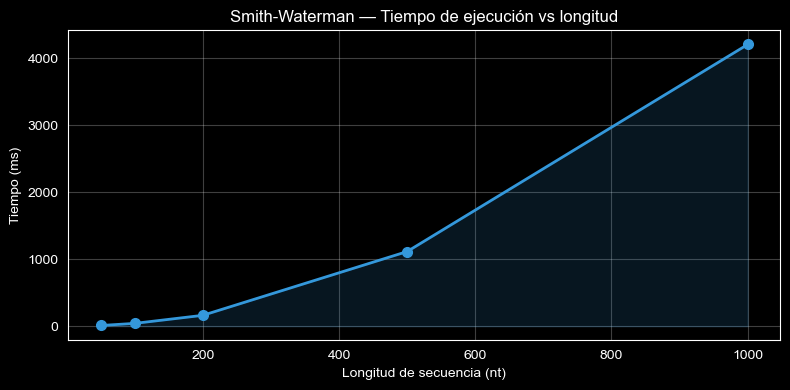

In [10]:
print("Medición de tiempo de ejecución — Smith-Waterman")
print()
print(f"  {'Long. (nt)':>10}  {'Celdas':>12}  {'Tiempo (ms)':>12}  {'ms/celda':>12}")
print(f"  {'':-<10}  {'':-<12}  {'':-<12}  {'':-<12}")

tiempos = []
longitudes_test = [50, 100, 200, 500, 1000]

for n in longitudes_test:
    if n > min(len(brca1_human), len(brca1_mouse)):
        break
    t0  = time.perf_counter()
    SmithWaterman(params).align(brca1_human[:n], brca1_mouse[:n])
    ms  = (time.perf_counter() - t0) * 1000
    celdas = (n+1) ** 2
    tiempos.append((n, celdas, ms))
    print(f"  {n:>10}  {celdas:>12,}  {ms:>12.2f}  {ms/celdas*1e6:>11.3f}μ")

print()
print("La complejidad O(n²) es evidente: duplicar la longitud cuadruplica el tiempo.")

fig, ax = plt.subplots(figsize=(8, 4))
ns  = [t[0] for t in tiempos]
ms_ = [t[2] for t in tiempos]
ax.plot(ns, ms_, 'o-', color='#3498db', linewidth=2, markersize=7)
ax.fill_between(ns, ms_, alpha=0.15, color='#3498db')
ax.set_xlabel("Longitud de secuencia (nt)")
ax.set_ylabel("Tiempo (ms)")
ax.set_title("Smith-Waterman — Tiempo de ejdef reconstruir_camino(H: np.ndarray, seq1: str, seq2: str,
                        params: ScoreParams) -> list[tuple[int,int]]:
    """Reconstruye el camino del traceback como lista de coordenadas (i, j)."""
    path = []
    i, j = map(int, np.unravel_index(np.argmax(H), H.shape))
    path.append((i, j))
    while i > 0 and j > 0 and H[i][j] > 0:
        if H[i][j] == H[i-1][j-1] + params.score(seq1[i-1], seq2[j-1]):
            i -= 1; j -= 1
        elif H[i][j] == H[i-1][j] + params.gap:
            i -= 1
        else:
            j -= 1
        path.append((i, j))
    return path


def plot_heatmap_traceback(result: AlignmentResult, seq1: str, seq2: str,
                            params: ScoreParams, ax: plt.Axes, title: str = ""):
    """Dibuja el heatmap con el camino del traceback resaltado."""
    H    = result.matrix
    path = reconstruir_camino(H, seq1, seq2, params)

    im = ax.imshow(H, cmap='Blues', aspect='auto', vmin=0)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Score')

    ax.set_xticks(range(len(seq2) + 1))
    ax.set_xticklabels(['-'] + list(seq2), fontsize=7.5, fontfamily='monospace')
    ax.set_yticks(range(len(seq1) + 1))
    ax.set_yticklabels(['-'] + list(seq1), fontsize=7.5, fontfamily='monospace')

    for ii in range(H.shape[0]):
        for jj in range(H.shape[1]):
            color = 'white' if H[ii, jj] > H.max() * 0.65 else '#222'
            ax.text(jj, ii, str(H[ii, jj]),
                    ha='center', va='center', fontsize=6.5, color=color)

    if len(path) > 1:
        py = [p[0] for p in path]
        px = [p[1] for p in path]
        ax.plot(px, py, 'r-', linewidth=2.2, zorder=5, label='Traceback')
        ax.plot(px[0],  py[0],  'r*', markersize=13, zorder=6,
                label=f'Inicio (score={H[py[0], px[0]]})')
        ax.plot(px[-1], py[-1], 'ko', markersize=7,  zorder=6,
                label='Fin (score=0)')

    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlabel("Seq2", fontsize=9)
    ax.set_ylabel("Seq1", fontsize=9)
    ax.set_title(f"{title}\nScore: {result.score}  |  Identidad: {result.identity:.1f}%",
                 fontsize=9)


N_viz = 20
s1_viz = brca1_human[:N_viz]
s2_viz = brca1_mouse[:N_viz]

res_sw_viz = SmithWaterman(params).align(s1_viz, s2_viz)
res_nw_viz = NeedlemanWunsch(params).align(s1_viz, s2_viz)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"BRCA1 Humano vs Ratón — Primeros {N_viz} nt\nHeatmap con camino del traceback",
             fontsize=12, fontweight='bold')

plot_heatmap_traceback(res_sw_viz, s1_viz, s2_viz, params, axes[0], "Smith-Waterman (local)")
plot_heatmap_traceback(res_nw_viz, s1_viz, s2_viz, params, axes[1], "Needleman-Wunsch (global)")

plt.tight_layout()
plt.show()

print("La línea roja muestra exactamente qué decisión tomó el algoritmo en cada paso:")
print("  Diagonal  → match o mismatch")
print("  Vertical  → gap en seq2")
print("  Horizontal → gap en seq1")
ecución vs longitud")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


## 12. Heatmap con Camino del Traceback Resaltado (Ejercicio 6)

El heatmap muestra la matriz de scoring completa:
- **Color más oscuro** indica mayor score acumulado
- **Línea roja** es el camino exacto del traceback (el alineamiento óptimo)
- **★** punto de inicio del traceback (celda con score máximo)
- **●** punto final (donde el score llega a 0)

Usamos 30 nt para que la matriz sea legible con los valores numéricos.


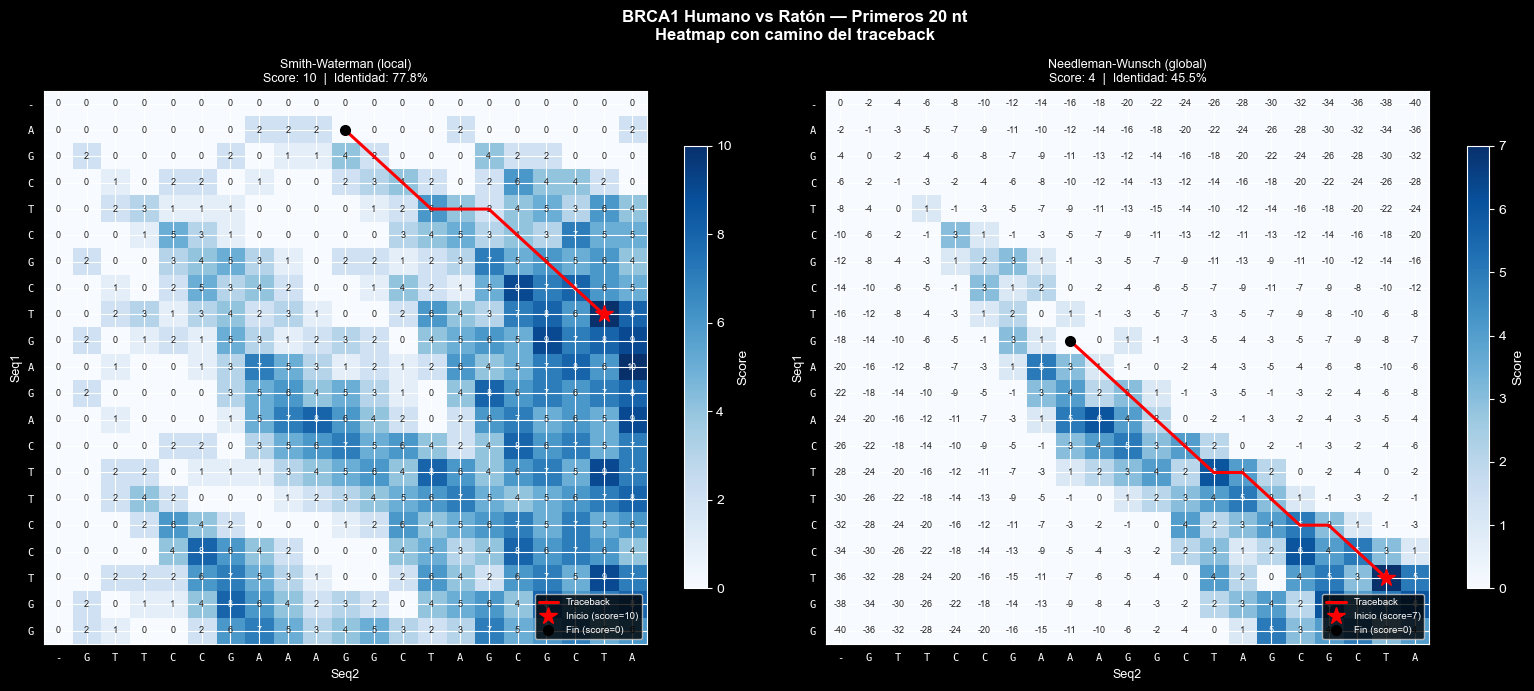

La línea roja muestra exactamente qué decisión tomó el algoritmo en cada paso:
  Diagonal  → match o mismatch
  Vertical  → gap en seq2
  Horizontal → gap en seq1


## 13. Preguntas de Reflexión

1. **¿Por qué Smith-Waterman nunca produce scores negativos en la matriz?
   ¿Qué consecuencia tiene esto para el alineamiento?**  
   _Responde aquí..._

2. **Con gap=-1 el alineamiento es más largo que con gap=-4.
   ¿En qué situación biológica conviene usar cada uno?**  
   _Responde aquí..._

3. **La complejidad de SW es O(n×m). Si quisieras comparar dos cromosomas
   de 200 Mbp cada uno, ¿cuántas celdas tendría la matriz?
   ¿Por qué BLAST es preferible en ese caso?**  
   _Responde aquí..._

4. **¿Qué indica biológicamente que BRCA1 humano y de ratón tengan
   alta identidad si divergieron hace ~87 millones de años?**  
   _Responde aquí..._

5. **En el heatmap, ¿qué diferencia visual notable hay entre la matriz
   de SW y la de NW? ¿Por qué?**  
   _Responde aquí..._

## 14. Conclusiones

- **Smith-Waterman** encuentra la región de mayor similitud local  ideal para
  genes que comparten dominios pero difieren en el resto
- **Needleman-Wunsch** alinea secuencias completas  ideal para homólogos
  de longitud similar
- El parámetro **gap** controla cuántas inserciones/deleciones permite el alineamiento
- La complejidad **O(n×m)** limita el uso directo a secuencias de cientos de nt;
  para genomas completos se usan heurísticas como BLAST
- El camino del **traceback** es la evidencia explícita de cada decisión del algoritmo

## 15. Referencias

- Smith, T.F. & Waterman, M.S. (1981). *Identification of common molecular subsequences.*
  Journal of Molecular Biology, 147(1), 195-197.
- Needleman, S.B. & Wunsch, C.D. (1970). *A general method applicable to the search
  for similarities in the amino acid sequence of two proteins.*
  Journal of Molecular Biology, 48(3), 443-453.
- NCBI BRCA1 humano: https://www.ncbi.nlm.nih.gov/nuccore/U14680.1
- NCBI BRCA1 ratón: https://www.ncbi.nlm.nih.gov/nuccore/NM_009764
